# Hierarchical clustering

- Test to establish a workflow for clustering the AC data I recorded

In [1]:
import datajoint as dj
import datetime
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import stackview as sv

from djimaging.utils import plot_utils, math_utils, trace_utils

# Create access to djimaging database

In [2]:
username = !whoami
username = username[0]
username

'fsalomon'

In [3]:
home_directory = os.path.expanduser("~")
home_directory

'/gpfs01/euler/User/fsalomon'

In [4]:
# Path to djimaging
path_to_djimaging = f'{home_directory}/github/eulerlab/'

# Clone djimaging if you haven't downloaded it yet
# assert os.isdir(path_to_djimaging), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging} && git clone git@github.com:eulerlab/djimaging.git

# Install djimaging if not done yet
# assert os.isdir(os.path.join(path_to_djimaging, 'djimaging')), 'Create target folder before cloning djimaging'
# !cd {path_to_djimaging}/djimaging/ && sudo pip install -e .

## Prepare dj config

In [5]:
# Set config file
config_file = f'{home_directory}/GitHub/docker/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [6]:
# Define a schema name or use the default name for your personal test schema
# It should start with ageuler and have some meaningful name after that
schema_name = f"ageuler_{username}_neuromodulation_ac"

In [7]:
# Do you want to use the RGC classifier?
# If so, make sure to add the respective tables into your schema.
use_rgc_classifier = False

if use_rgc_classifier:  # Define any existing outputfolder for the classifier to be saved
    output_folder = f'{home_directory}/datajoint/rgc_classifier'
    assert os.path.isdir(output_folder), f'Set path to output directory: {output_folder}'

In [8]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

if use_rgc_classifier:
    from djimaging.tables.classifier.rgc_classifier import prepare_dj_config_rgc_classifier
    prepare_dj_config_rgc_classifier(output_folder)

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-10-21 11:03:41,997][INFO]: DataJoint is configured from /gpfs01/euler/User/fsalomon/GitHub/docker/dj_fsalomon_conf.json
[2025-10-21 11:03:42,102][INFO]: DataJoint 0.14.6 connected to fsalomon@172.25.240.200:3306


schema_name: ageuler_fsalomon_neuromodulation_ac


DataJoint connection (connected) fsalomon@172.25.240.200:3306

## Load schema

In [9]:
# Import your own schema, which defines the tables you will have in your database and how they are connected.
from djimaging.user.neuromodulation_amacrine_cells.schemas.neuromodulation_amacrine_cells_schema import *

In [10]:
if use_rgc_classifier:
    try:
        CelltypeAssignment()
    except Exception as e:
        import warnings
        warnings.warn("""
            If you want to include the RGC classifier in your database, you have to copy the respective tables from 
            djimaging/schemas/full_rgc_schema.py 
            to the schema you just imported (see above).
            Then restart the notebook and try again.
            """)

In [11]:
from djimaging.utils.dj_utils import activate_schema

activate_schema(schema=schema, create_schema=True, create_tables=True)
schema

Schema `ageuler_fsalomon_neuromodulation_ac`

# Heatmaps

## Global chirp

- create heatmaps for data which was recorded from C1 and C2
- create heatmaps for data which was recorded from C1 and DETA/NO

### C1 vs C2
#### Fetsch Data

In [12]:
Averages() & {"date": datetime.date(2025, 9, 8), "stim_name": "gChirp"}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=


In [13]:
ChirpQI() & {"date": datetime.date(2025, 9, 8), "stim_name": "gChirp"}

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,1,1,0.205932,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,2,1,0.26708,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,3,1,0.23731,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,4,1,0.215393,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,5,1,0.223126,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,6,1,0.194005,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,7,1,0.279805,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,8,1,0.26186,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,9,1,0.24477,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,10,1,0.207242,0.2


In [14]:
# Take chirp averages from 08.09.2025 + add quality index from same data 
gchirp_quality = (Averages() & {"date": datetime.date(2025, 9, 8), "stim_name": "gChirp"}) * (ChirpQI() & {"date": datetime.date(2025, 9, 8), "stim_name": "gChirp"})
gchirp_quality

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,1,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.205932,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,2,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.26708,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.23731,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,4,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.215393,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,5,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.223126,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,6,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.194005,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.279805,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,8,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.26186,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,9,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.24477,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,10,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.207242,0.2


In [15]:
gchirp_quality & {"cond2": "C1"} & "qidx > 0.3"

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,16,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.306539,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,18,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.346453,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,21,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.30924,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,22,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.300514,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,26,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.355107,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,28,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.434344,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,36,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.310748,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,39,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.322063,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,49,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.309493,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,50,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.30932,0.2


In [16]:
# Filter for C1, C2, and DETANO + qidx > 0.3
C1 = gchirp_quality & {"cond2": "C1"} & "qidx > 0.3"
C2 = gchirp_quality & {"cond2": "C2"} & "qidx > 0.3"
DETANO = gchirp_quality & {"cond2": "DETANO"} & "qidx > 0.3"

In [17]:
# Filter C1 recordings which also have C2 recording
C1_with_C2 = C1 & (dj.U("field", "roi_id") & C2)
C1_with_C2

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,18,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.346453,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,36,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.310748,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,39,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.322063,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,49,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.309493,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,53,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.313014,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,58,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.37301,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,61,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.333725,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,67,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.308515,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,83,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.339927,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C1,84,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.302056,0.2


#### Heatmap C1

In [18]:
from djimaging.utils import plot_utils, math_utils, trace_utils

In [19]:
averages_norm = (C1_with_C2).fetch("average_norm")
averages_norm

array([array([ 0.02165611,  0.0212764 ,  0.02089668, ..., -0.00054552,
              -0.00054552, -0.00054552], shape=(16516,))              ,
       array([-0.55636741, -0.55479921, -0.55323101, ..., -0.6919164 ,
              -0.6919164 , -0.6919164 ], shape=(16516,))              ,
       array([-0.17181339, -0.17035367, -0.16889396, ..., -0.20613193,
              -0.20613193, -0.20613193], shape=(16516,))              ,
       array([-0.1355005 , -0.13778351, -0.14006652, ..., -0.05513851,
              -0.05513851, -0.05513851], shape=(16516,))              ,
       array([-0.58212557, -0.58828132, -0.59443707, ..., -0.39298575,
              -0.39298575, -0.39298575], shape=(16516,))              ,
       array([0.12242757, 0.12051685, 0.11860613, ..., 0.19367758, 0.19367758,
              0.19367758], shape=(16516,))                                    ,
       array([-0.22769781, -0.23195862, -0.23621943, ..., -0.11167481,
              -0.11167481, -0.11167481], shape=(16516,)

In [20]:
averages_norm = math_utils.padded_vstack(averages_norm, cval=np.nan)
averages_norm

array([[ 2.16561121e-02,  2.12763985e-02,  2.08966849e-02, ...,
        -5.45523867e-04, -5.45523867e-04, -5.45523867e-04],
       [-5.56367410e-01, -5.54799208e-01, -5.53231005e-01, ...,
        -6.91916397e-01, -6.91916397e-01, -6.91916397e-01],
       [-1.71813390e-01, -1.70353673e-01, -1.68893956e-01, ...,
        -2.06131926e-01, -2.06131926e-01, -2.06131926e-01],
       ...,
       [ 1.93586947e-01,  1.94119553e-01,  1.94652159e-01, ...,
         1.31242814e-01,  1.31242814e-01,  1.31242814e-01],
       [ 2.71419978e-01,  2.70740679e-01,  2.70061381e-01, ...,
         3.94612558e-01,  3.94612558e-01,  3.94612558e-01],
       [-1.39144175e-02, -1.35139931e-02, -1.31135688e-02, ...,
         2.18835220e-02,  2.18835220e-02,  2.18835220e-02]],
      shape=(360, 16516))

In [21]:
n = averages_norm.shape[0]
n

360

<Axes: >

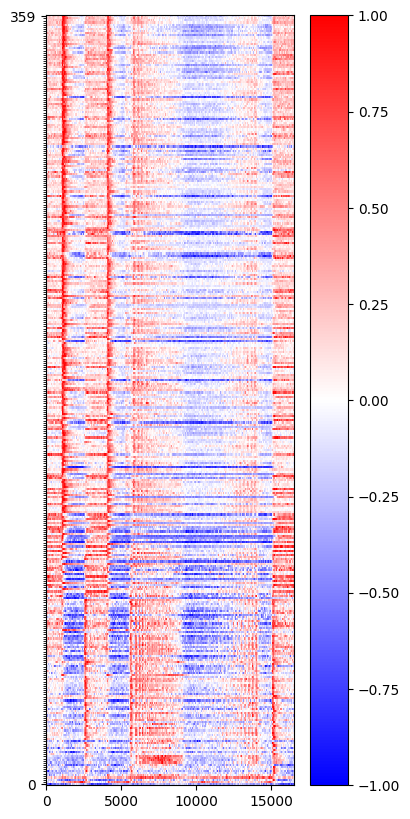

In [22]:
sort = True

fig, axs = plt.subplots(1, 1, figsize=(4, np.minimum(n * 0.1, 10)))

sort_idxs = trace_utils.argsort_traces(averages_norm, ignore_nan=True) if sort else np.arange(n)

plot_utils.plot_signals_heatmap(ax=axs, signals=averages_norm[sort_idxs, :])

In [23]:
def plot_signals_heatmap(signals, ax=None, cb=True, vabsmax=None, symmetric=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 3))

    if vabsmax is None:
        vabsmax = np.nanmax(np.abs(signals))

    if symmetric:
        vmin = -vabsmax
        vmax = vabsmax
        cmap = 'bwr'
    else:
        vmin = np.nanmin(signals)
        vmax = np.nanmax(signals)
        cmap = 'viridis'

    im = ax.imshow(signals, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap,
                   interpolation='none', origin='lower')
    if cb:
        plt.colorbar(im, ax=ax)

    #ax.set_yticks((0, signals.shape[0] - 1))
    #ax.set_yticks(np.arange(signals.shape[0]), minor=True)

    return ax

<Axes: >

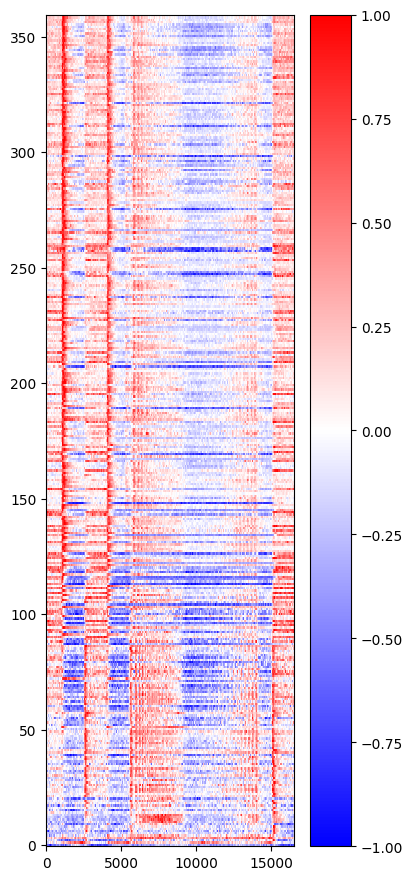

In [24]:
fig, axs = plt.subplots(1, 1, figsize=(4, n*0.03))

plot_signals_heatmap(ax=axs, signals=averages_norm[sort_idxs, :])

In [89]:
def plot_signals_heatmap(signals, ax=None, cb=True, vabsmax=None, symmetric=True):
    """
    Plot a clean heatmap of signals with consistent annotation bars for ROIs and time.
    """
    n_rois, n_timepoints = signals.shape

    # Create figure and axis if not provided
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, n_rois * 0.03))

    # Determine color limits
    if vabsmax is None:
        vabsmax = np.nanmax(np.abs(signals))

    if symmetric:
        vmin = -vabsmax
        vmax = vabsmax
        cmap = 'bwr'
    else:
        vmin = np.nanmin(signals)
        vmax = np.nanmax(signals)
        cmap = 'viridis'

    # Plot the heatmap
    im = ax.imshow(
        signals, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap,
        interpolation='none', origin='lower'
    )

    # Optionally add colorbar
    if cb:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Remove all axes, ticks, and frames
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # === Add annotation bars ===
    # Equal offset distance from plot
    offset_frac = 0.03  # fraction of axis size for consistent offset
    y_offset = -n_rois * offset_frac
    x_offset = -n_timepoints * offset_frac

    # --- Y-axis (ROIs) bar ---
    roi_bar_height = 50  # annotate 50 ROIs
    ax.plot(
        [x_offset, x_offset], [0, roi_bar_height],
        color='k', lw=2, clip_on=False
    )
    ax.text(
        x_offset * 1.2, roi_bar_height / 2, "50 ROIs",
        va='center', ha='right', rotation=90
    )

    # --- X-axis (time) bar ---
    total_time_s = 33  # total duration
    n_samples_5s = int(n_timepoints * (5 / total_time_s))
    ax.plot(
        [0, n_samples_5s], [y_offset, y_offset],
        color='k', lw=2, clip_on=False
    )
    ax.text(
        n_samples_5s / 2, y_offset * 1.4, "5 s",
        ha='center', va='top'
    )

    return ax

<Axes: >

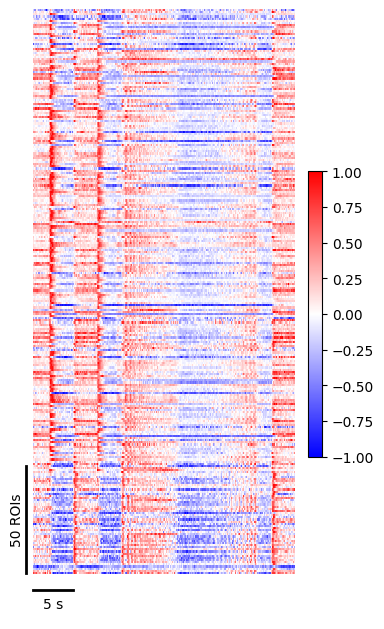

In [90]:
fig, axs = plt.subplots(1, 1, figsize=(4, n*0.03))

plot_signals_heatmap(ax=axs, signals=averages_norm[sort_idxs, :])

#### Heatmap C1 vs C2

In [91]:
C2_with_C1 = C2 & (dj.U("field", "roi_id") & C1)
C2_with_C1

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,18,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.454317,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,36,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.518837,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,39,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.317855,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,49,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.347551,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,53,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.331754,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,58,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.50804,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,61,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.357923,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,67,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.530535,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,83,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.412987,0.2
Salomon,2025-09-08,2,1,XY1,RR,v,gChirp,C2,84,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.391467,0.2


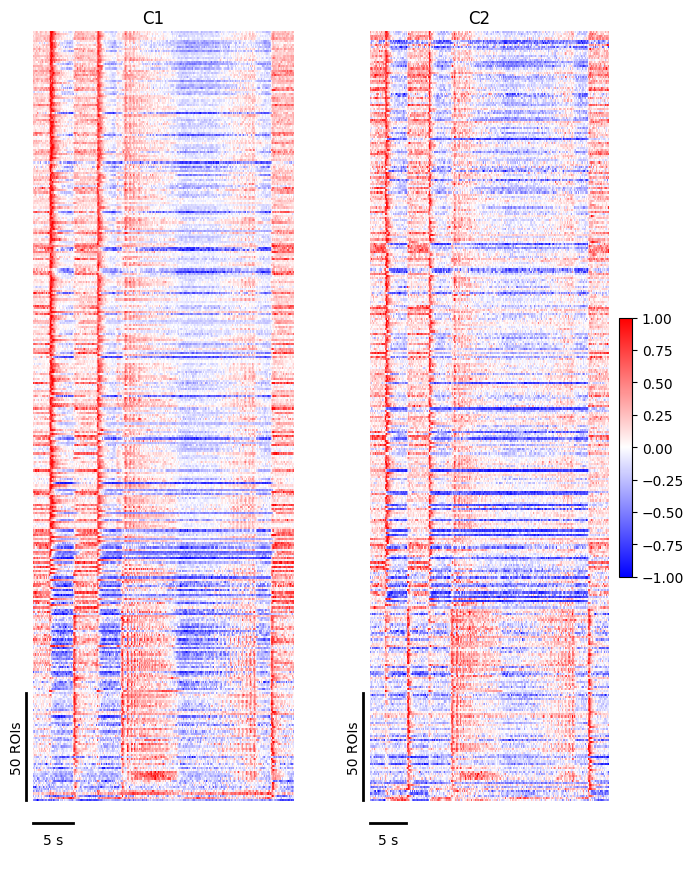

In [92]:
averages_norm_c1 = (C1_with_C2).fetch("average_norm")
averages_norm_c2 = (C2_with_C1).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_c2 = math_utils.padded_vstack(averages_norm_c2, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fig, axs = plt.subplots(1, 2, figsize=(8, n*0.03))

plot_signals_heatmap(ax=axs[0], signals=averages_norm_c1[sort_idxs, :], cb=False)

plot_signals_heatmap(ax=axs[1], signals=averages_norm_c2[sort_idxs, :])

axs[0].set_title("C1")
axs[1].set_title("C2")

plt.savefig("plots/20250908/chirp/heatmap_c1_vs_c2.png",
            dpi=300,
            bbox_inches="tight")

In [93]:
def plot_signals_heatmap_annotated_field(
    signals, ax=None, cb=True, vabsmax=None, symmetric=True,
    field_labels=None, field_colors=None, colorbar_width=0.03,
    legend=True
):
    """
    Plot a clean heatmap of signals with an optional color-coded bar for field annotations.

    Parameters
    ----------
    signals : array (n_rois, n_timepoints)
        The signal matrix to plot.
    ax : matplotlib axis, optional
        Axis to plot into.
    cb : bool
        Whether to add a colorbar for signal intensity.
    vabsmax : float
        Maximum absolute value for symmetric colormap scaling.
    symmetric : bool
        Whether to use symmetric color limits.
    field_labels : list of str, optional
        Field labels (e.g. 'XY1', 'XY2', ...) for each ROI (row).
    field_colors : dict, optional
        Mapping from field label -> color (e.g. {'XY1': 'red', 'XY2': 'blue', ...}).
        If None, automatically assigns colors.
    colorbar_width : float
        Fractional width of the color bar relative to main heatmap width.
    legend : bool
        Whether to show the legend mapping field colors.
    """
    n_rois, n_timepoints = signals.shape

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, n_rois * 0.03))
    fig = ax.figure  # always need figure for additional axes

    # Determine color limits
    if vabsmax is None:
        vabsmax = np.nanmax(np.abs(signals))

    if symmetric:
        vmin, vmax, cmap = -vabsmax, vabsmax, 'bwr'
    else:
        vmin, vmax, cmap = np.nanmin(signals), np.nanmax(signals), 'viridis'

    # Main heatmap
    im = ax.imshow(
        signals, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap,
        interpolation='none', origin='lower'
    )

    if cb:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.08)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # === Field color bar ===
    if field_labels is not None:
        field_labels = np.array(field_labels)

        unique_fields = np.unique(field_labels)
        if field_colors is None:
            cmap_fields = plt.get_cmap('tab10', len(unique_fields))
            field_colors = {f: cmap_fields(i) for i, f in enumerate(unique_fields)}

        # Build color bar as RGBA array
        color_bar = np.array([field_colors[f] for f in field_labels]).reshape(n_rois, 1, 4)

        # Create inset axis for the color bar
        bbox = ax.get_position()
        color_ax = fig.add_axes([
            bbox.x1 + colorbar_width * 0.5,
            bbox.y0,
            colorbar_width * 0.2,
            bbox.height
        ])
        color_ax.imshow(color_bar, aspect='auto', origin='lower')
        color_ax.set_xticks([])
        color_ax.set_yticks([])
        for spine in color_ax.spines.values():
            spine.set_visible(False)

        # Add legend (optional)
        if legend:
            legend_handles = [
                plt.Line2D([0], [0], color=field_colors[f], lw=6, label=f)
                for f in unique_fields
            ]
            ax.legend(
                handles=legend_handles, title="Field",
                bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False
            )

    return ax

In [94]:
fields_c1 = (C1_with_C2).fetch("field")
fields_c2 = (C2_with_C1).fetch("field")

In [95]:
fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_c2_sorted = np.array(fields_c2)[sort_idxs]

In [1]:
fig, axs = plt.subplots(1, 2, figsize=(8, n * 0.03))

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c1[sort_idxs, :],
    ax=axs[0],
    cb=False,
    field_labels=fields_c1_sorted,
    legend=False
)

plot_signals_heatmap_annotated_field(
    signals=averages_norm_c2[sort_idxs, :],
    ax=axs[1],
    cb=True,
    field_labels=fields_c2_sorted,
    legend=True
)

axs[0].set_title("C1")
axs[1].set_title("C2")

plt.savefig(
    "plots/20250908/chirp/heatmap_c1_vs_c2_annotated_field.png",
    dpi=300,
    bbox_inches="tight"
)

NameError: name 'plt' is not defined

### C1 vs DETA/NO

In [99]:
C1_with_DETANO = C1 & (dj.U("field", "roi_id") & DETANO)
C1_with_DETANO

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.442943,0.2
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,16,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.370169,0.2
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,C1,76,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.390248,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.312212,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,16,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.337109,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,20,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.310932,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,21,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.345367,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,26,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.338369,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,34,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.307663,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,C1,35,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.342616,0.2


In [100]:
DETANO_with_C1 = DETANO & (dj.U("field", "roi_id") & C1)
DETANO_with_C1

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,average array of snippet average (time),average_norm normalized array of snippet average (time),average_t0 time of the first sample of the average,average_dt time between samples of the average,triggertimes_rel array of relative triggertimes,qidx quality index as signal to noise ratio,min_qidx minimum quality index as 1/r (r = #repetitions)
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,DETANO,3,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.431485,0.2
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,DETANO,16,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.316613,0.2
Salomon,2025-09-08,2,1,XY2,RR,v,gChirp,DETANO,76,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.301633,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,7,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.439355,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,16,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.350661,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,20,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.44809,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,21,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.316045,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,26,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.519102,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,34,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.522319,0.2
Salomon,2025-09-08,2,1,XY4,RR,t,gChirp,DETANO,35,1,=BLOB=,=BLOB=,0.0,0.002,=BLOB=,0.393858,0.2


[2025-10-21 12:06:58,622][WARNING]: Reconnecting to MySQL server.


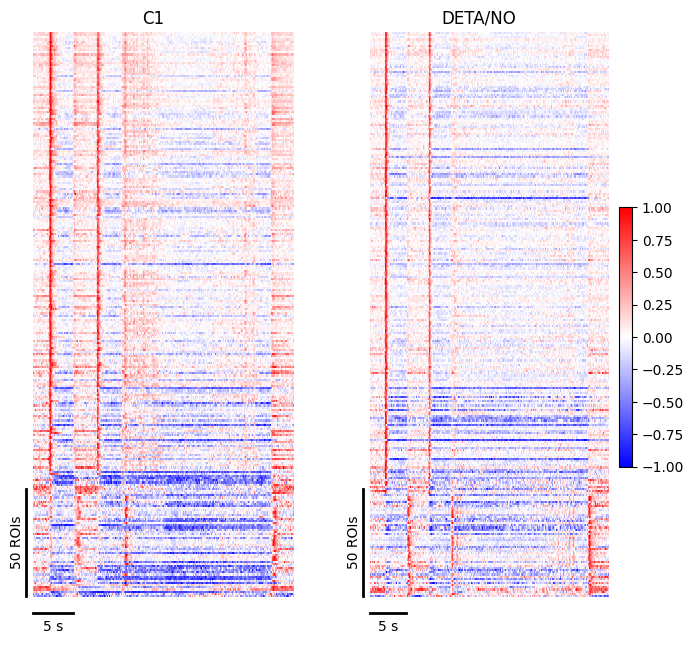

In [104]:
averages_norm_c1 = (C1_with_DETANO).fetch("average_norm")
averages_norm_detano = (DETANO_with_C1).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_detano = math_utils.padded_vstack(averages_norm_detano, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fig, axs = plt.subplots(1, 2, figsize=(8, n * 0.03))

plot_signals_heatmap(
    ax=axs[0],
    signals=averages_norm_c1[sort_idxs, :],
    cb=False
)

plot_signals_heatmap(
    ax=axs[1],
    signals=averages_norm_detano[sort_idxs, :]
)

axs[0].set_title("C1")
axs[1].set_title("DETA/NO")

plt.savefig("plots/20250908/chirp/heatmap_c1_vs_detano.png",
            dpi=300,
            bbox_inches="tight")

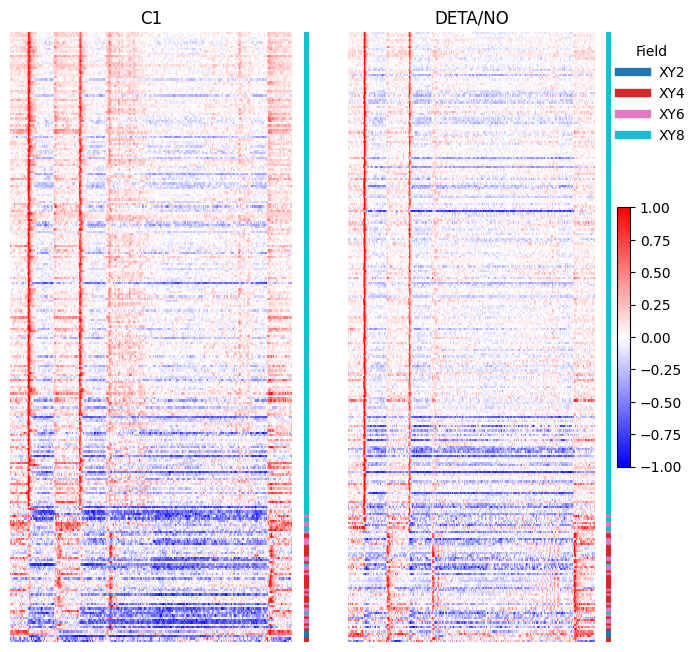

In [106]:
averages_norm_c1 = (C1_with_DETANO).fetch("average_norm")
averages_norm_detano = (DETANO_with_C1).fetch("average_norm")

averages_norm_c1 = math_utils.padded_vstack(averages_norm_c1, cval=np.nan)
averages_norm_detano = math_utils.padded_vstack(averages_norm_detano, cval=np.nan)

n = averages_norm_c1.shape[0]

sort = True

sort_idxs = trace_utils.argsort_traces(averages_norm_c1, ignore_nan=True) if sort else np.arange(n)

fields_c1 = (C1_with_DETANO).fetch("field")
fields_detano = (DETANO_with_C1).fetch("field")

fields_c1_sorted = np.array(fields_c1)[sort_idxs]
fields_detano_sorted = np.array(fields_detano)[sort_idxs]

fig, axs = plt.subplots(1, 2, figsize=(8, n * 0.03))

plot_signals_heatmap_annotated_field(
    ax=axs[0],
    signals=averages_norm_c1[sort_idxs, :],
    cb=False,
    field_labels=fields_c1_sorted,
    legend=False
)

plot_signals_heatmap_annotated_field(
    ax=axs[1],
    signals=averages_norm_detano[sort_idxs, :],
    field_labels=fields_detano_sorted,
    legend=True
)

axs[0].set_title("C1")
axs[1].set_title("DETA/NO")

plt.savefig("plots/20250908/chirp/heatmap_c1_vs_detano_annotated_field.png",
            dpi=300,
            bbox_inches="tight")